In [3]:
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.signal import savgol_filter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
import tensorflow.keras.backend as K
import os

2026-04-30 14:06:47.763064: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777558007.977167      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777558008.047225      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777558008.567241      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777558008.567286      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777558008.567289      57 computation_placer.cc:177] computation placer alr

In [4]:
# ─────────────────────────────────────────────
def process_grain_d(file_path, num_points=100):
    """
    Reads the Grain-D CSV and returns:
        X        : (N, 5)   input features
        y_thrust : (N, 100) thrust profile
        y_pressure:(N, 100) pressure profile
        y_scalars: (N, 4)   [ISP, Total_Impulse, Burn_Time, Max_Thrust]
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")

    df = pd.read_csv(file_path, on_bad_lines='skip', skip_blank_lines=True)

    # ── كول الـ ID الصح لـ Grain D
    df['Model_ID'] = pd.to_numeric(df['Model_ID'], errors='coerce')
    df = df.dropna(subset=['Model_ID'])

    # ── 5 أبعاد الـ Grain D
    INPUT_COLS   = ['Length', 'Diameter', 'Slot_Offset', 'Throat_Diameter', 'Exit_Diameter']
    # ── أعمدة الـ scalars (ثابتة لكل ID)
    SCALAR_COLS  = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)']

    X, y_thrust, y_pressure, y_scalars = [], [], [], []

    for uid in df['Model_ID'].unique():
        try:
            case = df[df['Model_ID'] == uid].sort_values('Time (s)')

            inputs = case[INPUT_COLS].iloc[0].values.astype(float)
            if np.any(inputs <= 0):
                continue

            t        = case['Time (s)'].values
            thrust   = case['Thrust (N)'].fillna(0).values
            pressure = case['Pressure (MPa)'].fillna(0).values

            if len(t) < 2 or t[-1] <= 0:
                continue

            # تنعيم Savitzky-Golay
            if len(thrust) > 7:
                thrust   = savgol_filter(thrust,   window_length=7, polyorder=3)
                pressure = savgol_filter(pressure, window_length=7, polyorder=3)

            # إعادة التشكيل على 100 نقطة موحّدة
            x_new = np.linspace(t[0], t[-1], num_points)
            interp_t = interp1d(t, thrust,   kind='linear', fill_value='extrapolate')
            interp_p = interp1d(t, pressure, kind='linear', fill_value='extrapolate')

            scalars = case[SCALAR_COLS].iloc[0].values.astype(float)

            X.append(inputs)
            y_thrust.append(interp_t(x_new))
            y_pressure.append(interp_p(x_new))
            y_scalars.append(scalars)

        except Exception as e:
            print(f"Skipping ID {uid}: {e}")
            continue

    
    return (np.array(X, dtype=float),
            np.array(y_thrust,   dtype=float),
            np.array(y_pressure, dtype=float),
            np.array(y_scalars,  dtype=float))

In [5]:
import pandas as pd

FILE_PATH = '/kaggle/input/datasets/mahmoudabdelrazek11/d-data/D_core_Dataset.csv'

df = pd.read_csv(FILE_PATH, on_bad_lines='skip', nrows=5)

print("COLUMN NAMES:")
for i, col in enumerate(df.columns):
    print(f"  [{i:02d}]  {repr(col)}")

print("\nFirst row:")
print(df.iloc[0].to_dict())

COLUMN NAMES:
  [00]  'Time (s)'
  [01]  'Pressure (MPa)'
  [02]  'Thrust (N)'
  [03]  'Length'
  [04]  'Diameter'
  [05]  'Slot_Offset'
  [06]  'Throat_Diameter'
  [07]  'Exit_Diameter'
  [08]  'Total Impulse (Ns)'
  [09]  'ISP (s)'
  [10]  'Max Thrust (N)'
  [11]  'Peak Pressure (MPa)'
  [12]  'Burn Time (s)'
  [13]  'Avg Thrust (N)'
  [14]  'Model_ID'
  [15]  'Grain_Type'

First row:
{'Time (s)': 0.0, 'Pressure (MPa)': 2.12146881924772, 'Thrust (N)': 0.0, 'Length': 20, 'Diameter': 6, 'Slot_Offset': 1.0, 'Throat_Diameter': 0.8, 'Exit_Diameter': 1.2, 'Total Impulse (Ns)': 1120.676784459292, 'ISP (s)': 156.7624125572271, 'Max Thrust (N)': 146.4718860923747, 'Peak Pressure (MPa)': 2.355131729344004, 'Burn Time (s)': 11.35500000000038, 'Avg Thrust (N)': 98.6511253925434, 'Model_ID': 1, 'Grain_Type': 'Moon'}


In [6]:
# ─────────────────────────────────────────────
FILE_PATH = '/kaggle/input/datasets/mahmoudabdelrazek11/d-data/D_core_Dataset.csv'

X, yt, yp, ys = process_grain_d(FILE_PATH)

print(f"Loaded  → X: {X.shape} | Thrust: {yt.shape} | Pressure: {yp.shape} | Scalars: {ys.shape}")

# ── Sanity check: تأكد إن مفيش NaN
assert not np.isnan(X).any(),  "NaN found in X!"
assert not np.isnan(yt).any(), "NaN found in Thrust!"
assert not np.isnan(yp).any(), "NaN found in Pressure!"
assert not np.isnan(ys).any(), "NaN found in Scalars!"

Loaded  → X: (3790, 5) | Thrust: (3790, 100) | Pressure: (3790, 100) | Scalars: (3790, 4)


In [7]:
# ─────────────────────────────────────────────
X_train, X_test, yt_train, yt_test, yp_train, yp_test, ys_train, ys_test = \
    train_test_split(X, yt, yp, ys, test_size=0.15, random_state=42)

# RobustScaler للـ inputs عشان يتعامل مع Outliers
s_X  = RobustScaler()
X_tr = s_X.fit_transform(X_train)
X_te = s_X.transform(X_test)

# StandardScaler للـ outputs
s_yt = StandardScaler();  yt_tr = s_yt.fit_transform(yt_train)
s_yp = StandardScaler();  yp_tr = s_yp.fit_transform(yp_train)
s_ys = StandardScaler();  ys_tr = s_ys.fit_transform(ys_train)

In [ ]:
# ─────────────────────────────────────────────
def shape_matching_loss(y_true, y_pred):
    mse        = K.mean(K.square(y_true - y_pred))
    diff_true  = y_true[:, 1:] - y_true[:, :-1]
    diff_pred  = y_pred[:, 1:] - y_pred[:, :-1]
    shape_loss = K.mean(K.square(diff_true - diff_pred))
    return mse + 10.0 * shape_loss

In [9]:
# ─────────────────────────────────────────────
NUM_TIMESTEPS = 100   # عدد نقاط المنحنى
NUM_INPUTS    = 5     # عدد أبعاد Grain D

def curve_branch_lstm(shared, nodes, timesteps, name):
    """يبني منحنى زمني 100 نقطة من الـ shared features"""
    b = layers.Dense(nodes // 2, activation='relu')(shared)
    b = layers.BatchNormalization()(b)
    b = layers.RepeatVector(timesteps)(b)          # (batch, 100, nodes//2)
    b = layers.LSTM(128, return_sequences=True)(b)
    b = layers.LSTM(64,  return_sequences=True)(b)
    b = layers.TimeDistributed(layers.Dense(1))(b)
    return layers.Flatten(name=name)(b)            # (batch, 100)

def scalar_branch(shared, nodes, out_dim, name):
    """يبني الـ scalars الثابتة (ISP, Impulse, …)"""
    b = layers.Dense(nodes,       activation='relu')(shared)
    b = layers.Dense(nodes // 2,  activation='relu')(b)
    return layers.Dense(out_dim, name=name)(b)


# ── Input layer (5 بدل 7 في Star grain)
inp = layers.Input(shape=(NUM_INPUTS,), name='grain_d_input')

# ── Feature extraction
x = layers.Dense(1024, activation='relu')(inp)
x = layers.BatchNormalization()(x)

# ── Residual Block 1
r1 = layers.Dense(1024, activation='relu')(x)
r1 = layers.BatchNormalization()(r1)
r1 = layers.Dense(1024, activation='relu')(r1)
x  = layers.Add()([x, r1])
x  = layers.Dropout(0.2)(x)

# ── Residual Block 2
r2 = layers.Dense(1024, activation='relu')(x)
r2 = layers.BatchNormalization()(r2)
r2 = layers.Dense(1024, activation='relu')(r2)
shared = layers.Add()([x, r2])
shared = layers.Dropout(0.2)(shared)

# ── Output branches
out_thrust   = curve_branch_lstm(shared, 1024, NUM_TIMESTEPS, 'Thrust')
out_pressure = curve_branch_lstm(shared, 1024, NUM_TIMESTEPS, 'Pressure')
out_scalars  = scalar_branch(shared, 512, 4, 'Scalars')

model = Model(inputs=inp, outputs=[out_thrust, out_pressure, out_scalars])
model.summary()

# ── Compile
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss={
        'Thrust':   shape_matching_loss,
        'Pressure': shape_matching_loss,
        'Scalars':  'mae'
    },
    loss_weights={'Thrust': 1.0, 'Pressure': 1.0, 'Scalars': 0.1}
)

I0000 00:00:1777558148.072804      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777558148.078632      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ grain_d_input       │ (None, 5)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1024)      │      6,144 │ grain_d_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1024)      │      4,096 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1024)      │  1,049,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1024)      │  1,049,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1024)      │          0 │ batch_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1024)      │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1024)      │  1,049,600 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1024)      │  1,049,600 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1024)      │          0 │ dropout[0][0],    │
│                     │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1024)      │          0 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 512)       │    524,800 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 512)       │    524,800 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_5[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_7[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector       │ (None, 100, 512)  │          0 │ batch_normalizat… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat_vector_1     │ (None, 100, 512)  │          0 │ batch_normalizat… │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 100, 128)  │    328,192 │ repeat_vector[0]

 Total params: 6,683,014 (25.49 MB)

 Trainable params: 6,674,822 (25.46 MB)

 Non-trainable params: 8,192 (32.00 KB)

In [10]:
# ─────────────────────────────────────────────
callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=15,
                      min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=60,
                  restore_best_weights=True)
]

history = model.fit(
    X_tr,
    [yt_tr, yp_tr, ys_tr],
    validation_split=0.15,
    epochs=500,
    batch_size=32,
    verbose=1,
    callbacks=callbacks
)

Epoch 1/500


I0000 00:00:1777558166.926594     129 cuda_dnn.cc:529] Loaded cuDNN version 91002


86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 82ms/step - Pressure_loss: 0.5756 - Scalars_loss: 0.7460 - Thrust_loss: 0.4446 - loss: 1.0948 - val_Pressure_loss: 0.8610 - val_Scalars_loss: 0.7530 - val_Thrust_loss: 0.8103 - val_loss: 1.7817 - learning_rate: 0.0010
Epoch 2/500
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - Pressure_loss: 0.4225 - Scalars_loss: 0.3278 - Thrust_loss: 0.3178 - loss: 0.7730 - val_Pressure_loss: 0.8999 - val_Scalars_loss: 0.7264 - val_Thrust_loss: 0.8277 - val_loss: 1.8416 - learning_rate: 0.0010
Epoch 3/500
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - Pressure_loss: 0.3820 - Scalars_loss: 0.2833 - Thrust_loss: 0.3219 - loss: 0.7323 - val_Pressure_loss: 0.8817 - val_Scalars_loss: 0.6972 - val_Thrust_loss: 0.8875 - val_loss: 1.8897 - learning_rate: 0.0010
Epoch 4/500
86/86 ━━━━━━━━━━━━━━━━━━━━ 4s 51ms/step - Pressure_loss: 0.3891 - Scalars_loss: 0.2513 - Thrust_loss: 0.2958 - loss: 0.7099 - val_Pressure_loss: 0.8533 - val_Scalars_loss: 0.6483 - val_Thrust_loss: 0.7264 - val_loss: 1.

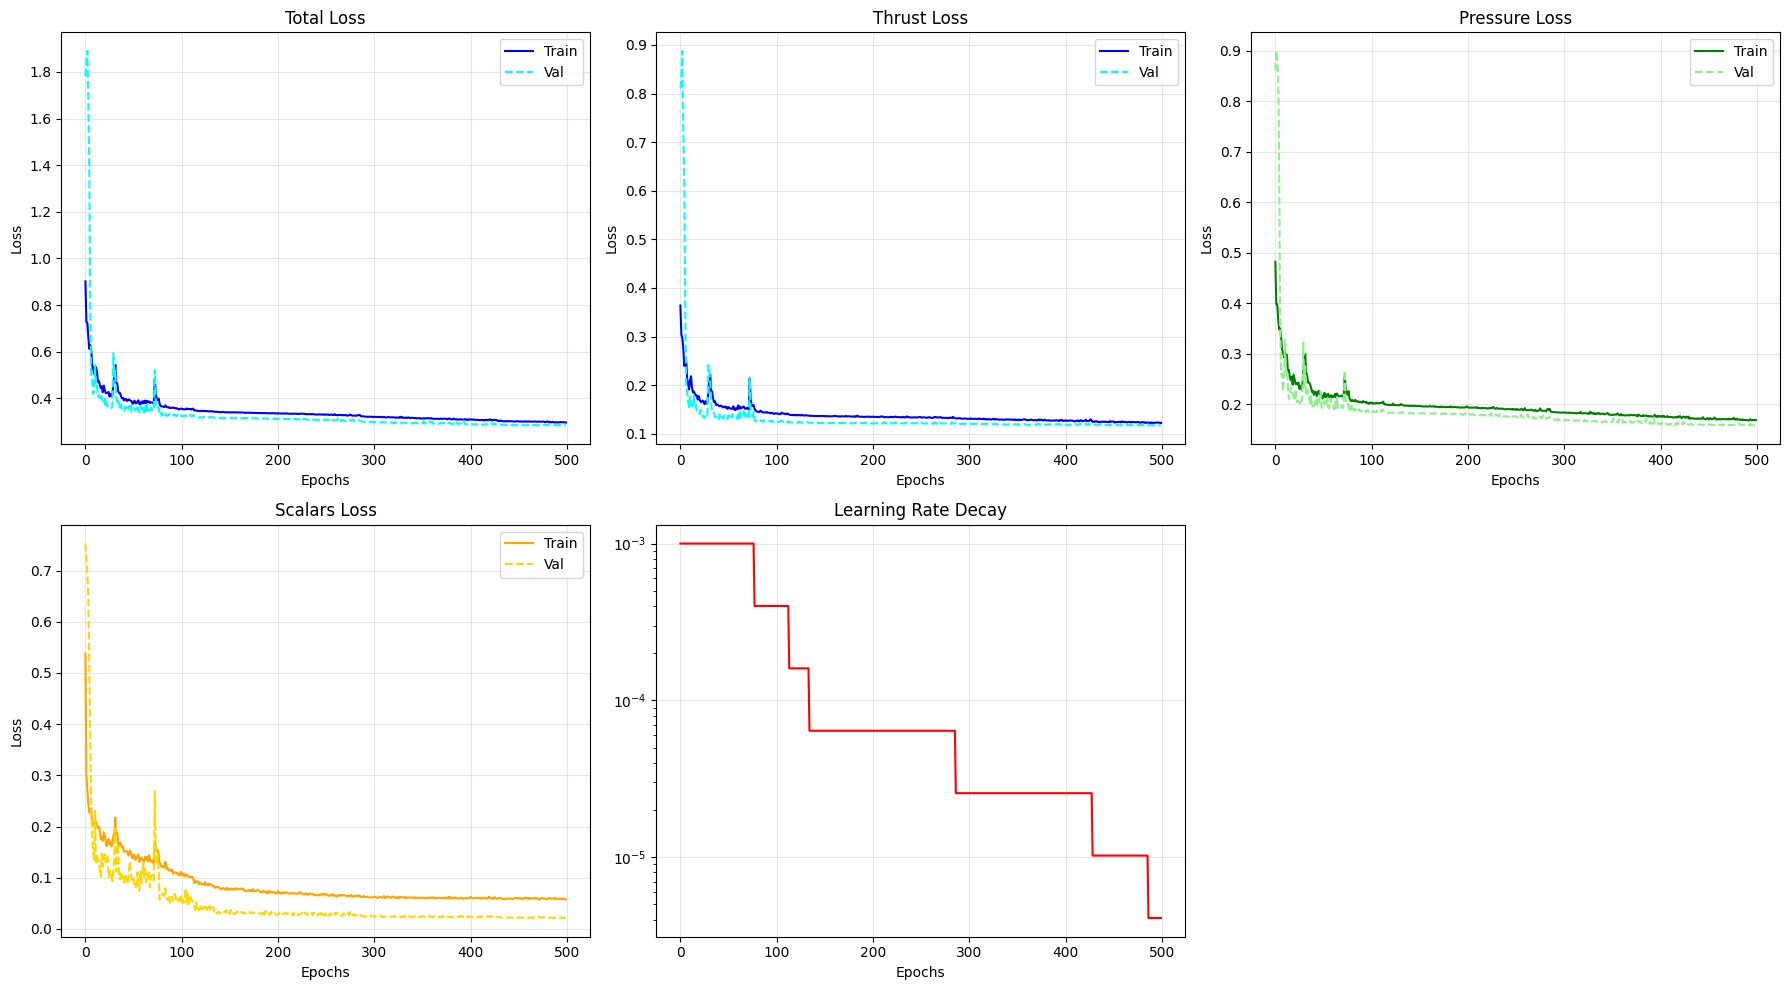

In [11]:
# ─────────────────────────────────────────────
plt.figure(figsize=(18, 10))

plots = [
    ('loss',          'val_loss',          'Total Loss',    'blue',   'cyan'),
    ('Thrust_loss',   'val_Thrust_loss',   'Thrust Loss',   'blue',   'cyan'),
    ('Pressure_loss', 'val_Pressure_loss', 'Pressure Loss', 'green',  'lightgreen'),
    ('Scalars_loss',  'val_Scalars_loss',  'Scalars Loss',  'orange', 'gold'),
]

for i, (tr_key, val_key, title, tc, vc) in enumerate(plots, 1):
    plt.subplot(2, 3, i)
    plt.plot(history.history[tr_key],  label='Train', color=tc)
    plt.plot(history.history[val_key], label='Val',   color=vc, linestyle='--')
    plt.title(title);  plt.xlabel('Epochs');  plt.ylabel('Loss')
    plt.legend();  plt.grid(True, alpha=0.3)

plt.subplot(2, 3, 5)
plt.plot(history.history['learning_rate'], color='red')
plt.title('Learning Rate Decay');  plt.xlabel('Epochs')
plt.yscale('log');  plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grain_d_loss_curves.png', dpi=150)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


/tmp/ipykernel_57/951592412.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_57/951592412.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'grain_d_sample_{idx}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


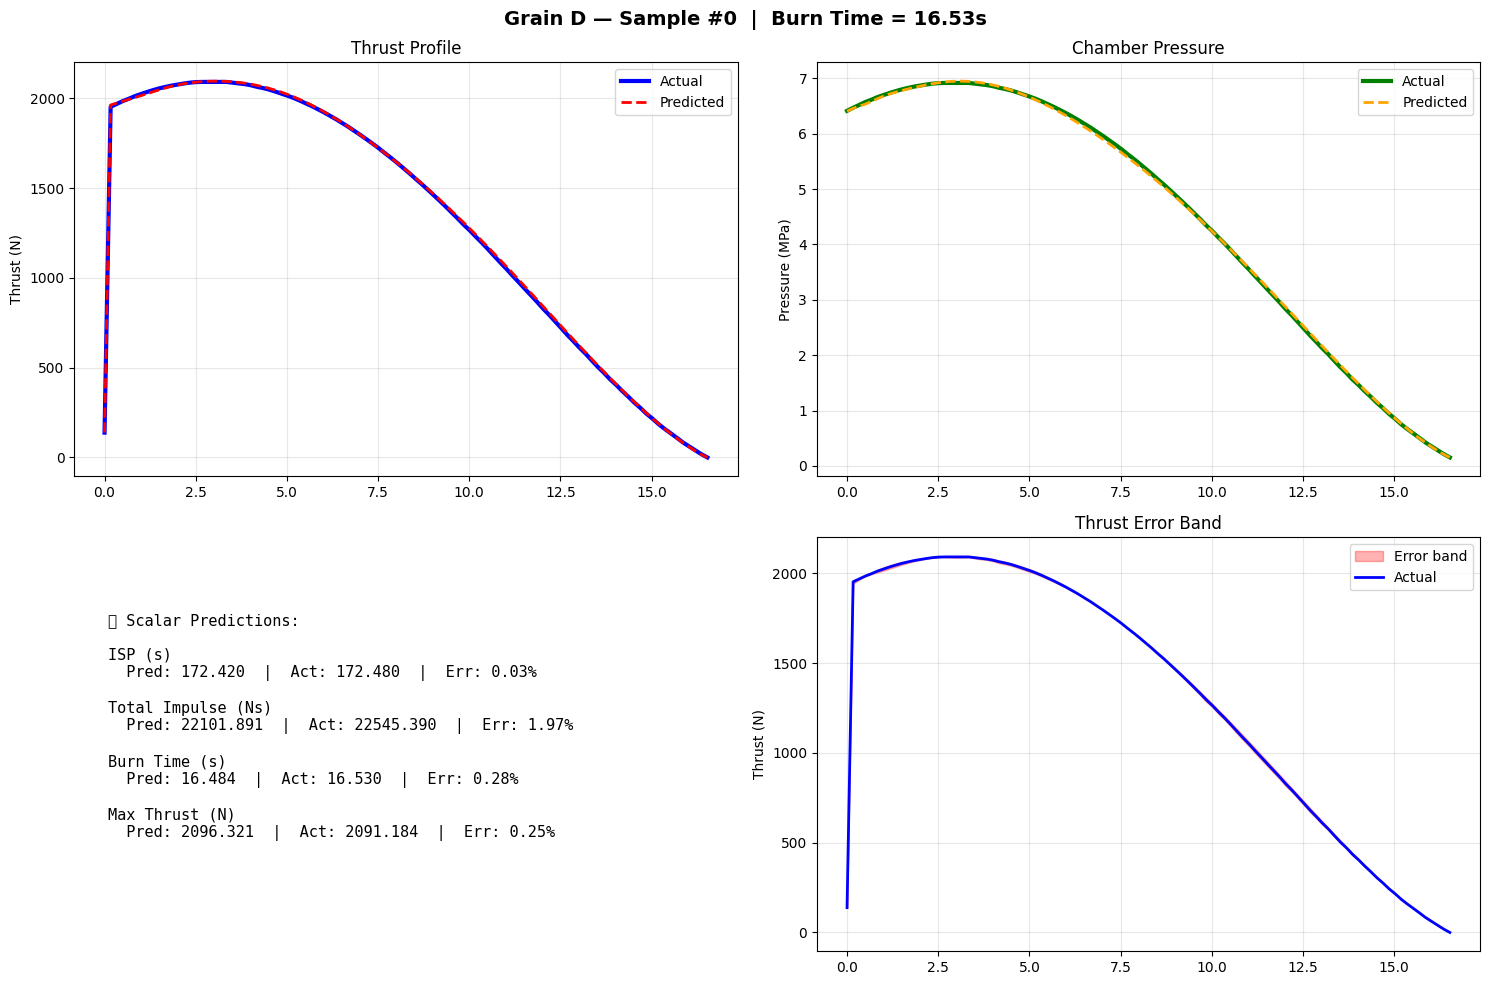

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/tmp/ipykernel_57/951592412.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_57/951592412.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'grain_d_sample_{idx}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


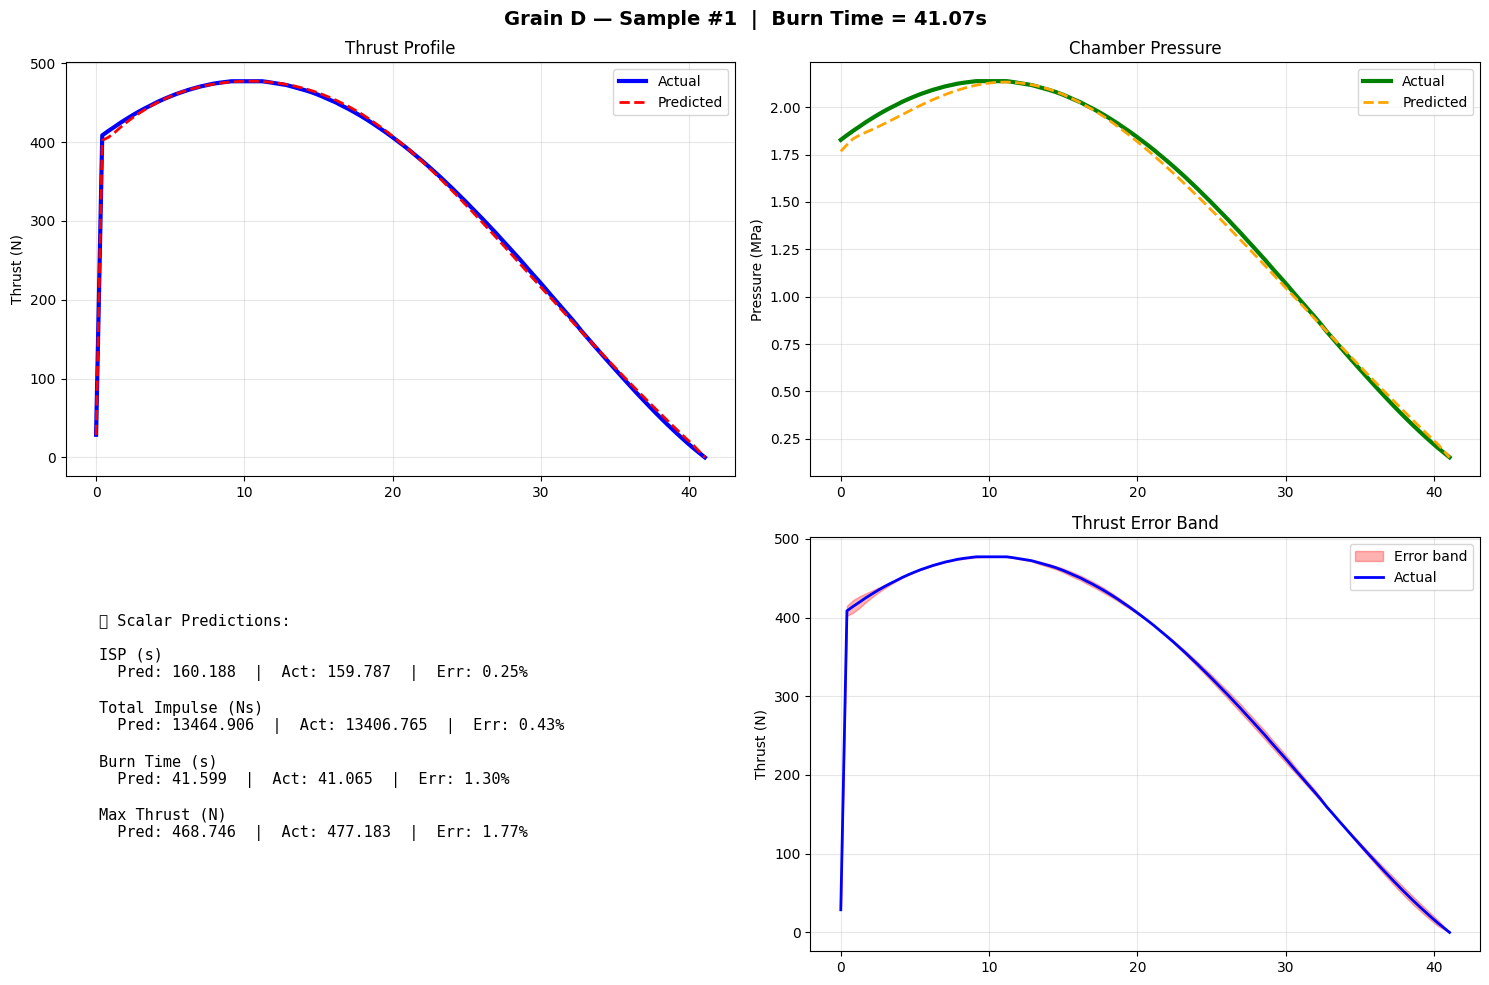

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


/tmp/ipykernel_57/951592412.py:51: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout()
/tmp/ipykernel_57/951592412.py:52: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(f'grain_d_sample_{idx}.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


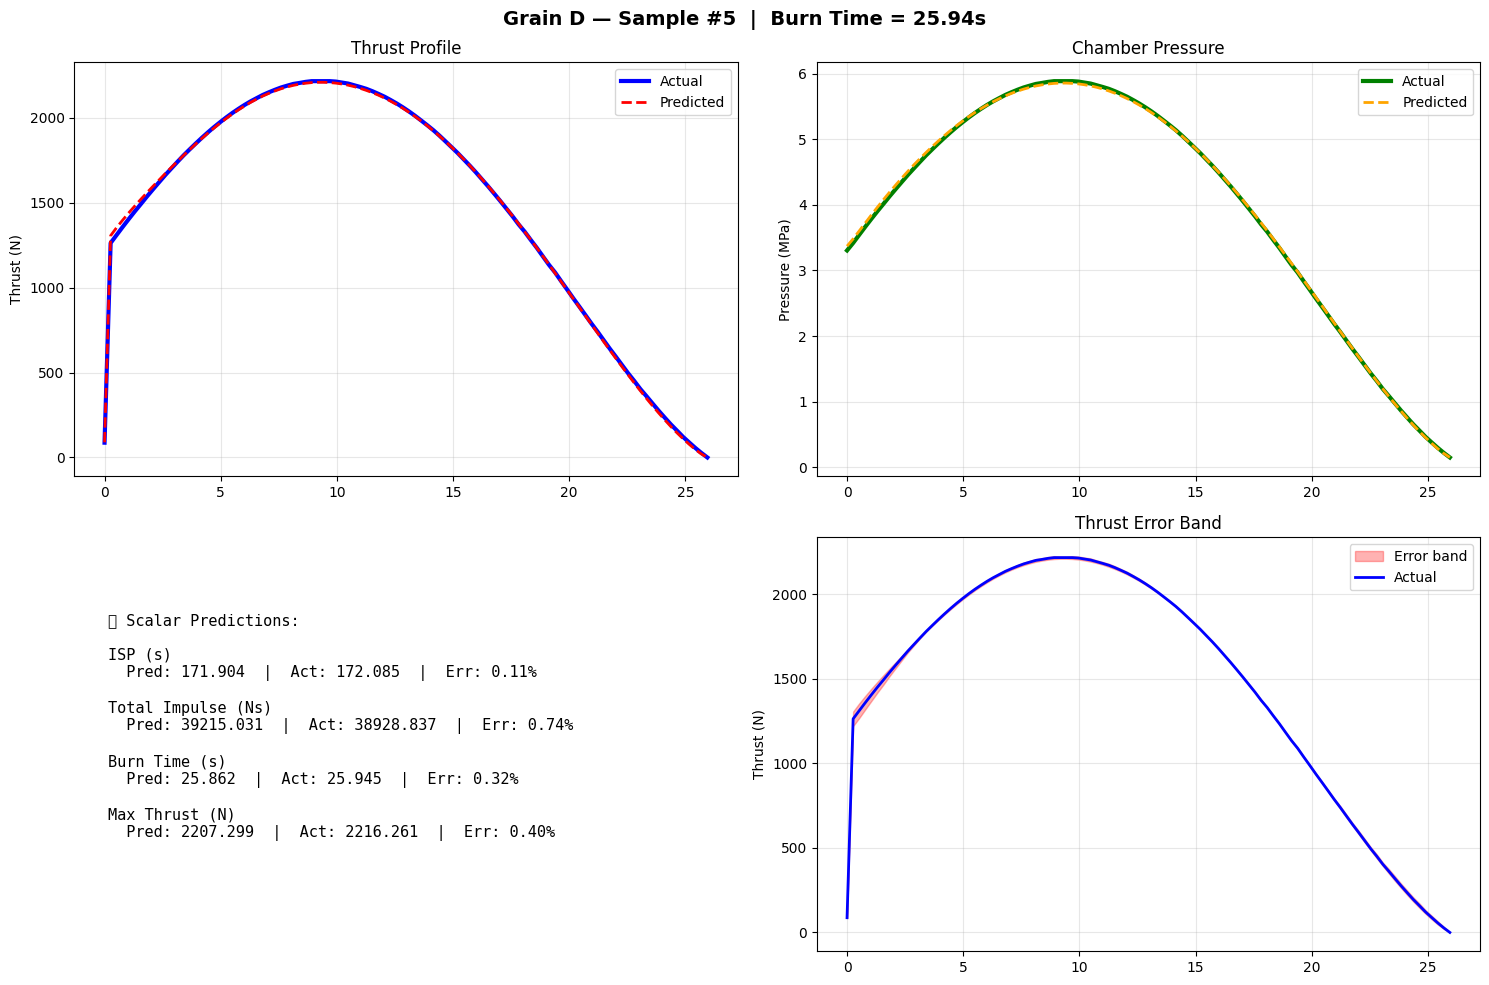

In [12]:
# ─────────────────────────────────────────────
def evaluate_sample(idx=0):
    sample_in = X_te[idx:idx+1]
    preds     = model.predict(sample_in)

    pred_thrust   = s_yt.inverse_transform(preds[0])[0]
    pred_pressure = s_yp.inverse_transform(preds[1])[0]
    pred_scalars  = s_ys.inverse_transform(preds[2])[0]

    act_thrust    = yt_test[idx]
    act_pressure  = yp_test[idx]
    act_scalars   = ys_test[idx]

    burn_time  = act_scalars[2]                          # index 2 = Burn Time
    time_axis  = np.linspace(0, burn_time, 100)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Grain D — Sample #{idx}  |  Burn Time = {burn_time:.2f}s',
                 fontsize=14, fontweight='bold')

    # Thrust
    axes[0, 0].plot(time_axis, act_thrust,    'b-',  label='Actual',    lw=3)
    axes[0, 0].plot(time_axis, pred_thrust,   'r--', label='Predicted', lw=2)
    axes[0, 0].set_title('Thrust Profile');  axes[0, 0].set_ylabel('Thrust (N)')
    axes[0, 0].legend();  axes[0, 0].grid(True, alpha=0.3)

    # Pressure
    axes[0, 1].plot(time_axis, act_pressure,  'g-',      label='Actual',    lw=3)
    axes[0, 1].plot(time_axis, pred_pressure, 'orange',  label='Predicted', lw=2, linestyle='--')
    axes[0, 1].set_title('Chamber Pressure');  axes[0, 1].set_ylabel('Pressure (MPa)')
    axes[0, 1].legend();  axes[0, 1].grid(True, alpha=0.3)

    # Scalars summary
    labels = ['ISP (s)', 'Total Impulse (Ns)', 'Burn Time (s)', 'Max Thrust (N)']
    axes[1, 0].axis('off')
    txt = "📊 Scalar Predictions:\n\n"
    for i, lbl in enumerate(labels):
        err = abs(pred_scalars[i] - act_scalars[i]) / (act_scalars[i] + 1e-9) * 100
        txt += f"{lbl}\n  Pred: {pred_scalars[i]:.3f}  |  Act: {act_scalars[i]:.3f}  |  Err: {err:.2f}%\n\n"
    axes[1, 0].text(0.05, 0.5, txt, fontsize=11, family='monospace', va='center')

    # Thrust error band
    axes[1, 1].fill_between(time_axis,
                             act_thrust - np.abs(pred_thrust - act_thrust),
                             act_thrust + np.abs(pred_thrust - act_thrust),
                             alpha=0.3, color='red', label='Error band')
    axes[1, 1].plot(time_axis, act_thrust, 'b-', lw=2, label='Actual')
    axes[1, 1].set_title('Thrust Error Band');  axes[1, 1].set_ylabel('Thrust (N)')
    axes[1, 1].legend();  axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'grain_d_sample_{idx}.png', dpi=150)
    plt.show()

# جرب عينات مختلفة
evaluate_sample(0)
evaluate_sample(1)
evaluate_sample(5)

In [13]:
# ─────────────────────────────────────────────
def detect_overfitting(history, threshold=0.1):
    train_loss = history.history['loss'][-1]
    val_loss   = history.history['val_loss'][-1]
    gap        = (val_loss - train_loss) / train_loss

    print("=" * 40)
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val   Loss : {val_loss:.4f}")
    print(f"Gap        : {gap:.2%}")
    if gap > threshold:
        print("⚠️  Overfitting detected — consider more dropout or less capacity.")
    else:
        print("✅  Model is well-balanced.")
    print("=" * 40)

detect_overfitting(history)

Train Loss : 0.2963
Val   Loss : 0.2838
Gap        : -4.19%
✅  Model is well-balanced.


In [14]:
# ─────────────────────────────────────────────
import pickle

model.save('grain_d_model.keras')
print("✅ Model saved → grain_d_model.keras")

with open('grain_d_scalers.pkl', 'wb') as f:
    pickle.dump({'s_X': s_X, 's_yt': s_yt, 's_yp': s_yp, 's_ys': s_ys}, f)
print("✅ Scalers saved → grain_d_scalers.pkl")

✅ Model saved → grain_d_model.keras
✅ Scalers saved → grain_d_scalers.pkl


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def get_user_input_and_predict_grain_d():
    print("\n" + "="*50)
    print("--- Enter the dimensions of Grain D for prediction ---")
    print("="*50)
    try:
        # 1. استلام المدخلات الصحيحة لنموذج Grain D
        l_val = float(input("Length: "))
        d_val = float(input("Diameter: "))
        so_val = float(input("Slot Offset: "))
        t_d_val = float(input("Throat Diameter: "))
        e_d_val = float(input("Exit Diameter: "))
        
        # ترتيب المدخلات لنموذج Grain D لتتطابق مع INPUT_COLS
        user_inputs = np.array([[l_val, d_val, so_val, t_d_val, e_d_val]])
        user_inputs_scaled = s_X.transform(user_inputs)
        
        # 2. Prediction
        preds = model.predict(user_inputs_scaled, verbose=0)
        
        # 3. فك التشفير
        thrust_pred = s_yt.inverse_transform(preds[0])
        pressure_pred = s_yp.inverse_transform(preds[1])
        scalars_pred = s_ys.inverse_transform(preds[2])
        
        # 4. استخراج القيم الأربعة 
        isp = scalars_pred[0][0]
        predicted_impulse = scalars_pred[0][1]
        burn_time = scalars_pred[0][2]
        max_thrust = scalars_pred[0][3]
        
        # Preparing the timeline
        time_steps = np.linspace(0, burn_time, 100)
        
        # حساب المساحة تحت المنحنى باستخدام trapezoid
        calculated_impulse = np.trapezoid(thrust_pred[0], time_steps)        
        
        print("\n" + "-"*40)
        print("--- Predicted Performance Results (Grain D) ---")
        print("-"*40)
        print(f"ISP: {isp:.2f} s")
        print(f"Total Impulse (Model): {predicted_impulse:.2f} N.s")
        print(f"Total Impulse (Calculated Area): {calculated_impulse:.2f} N.s")
        print(f"Burn Time: {burn_time:.2f} s")
        print(f"Max Thrust: {max_thrust:.2f} N")
        print("-"*40 + "\n")
        
        # رسم النتائج (بدون فلاتر تنعيم للحفاظ على الشكل الفيزيائي الحقيقي للمنحنى)
        plt.figure(figsize=(15, 5))
        
        # (Thrust Plot)
        plt.subplot(1, 2, 1)
        plt.plot(time_steps, thrust_pred[0], color='red', linewidth=2)
        plt.title('Predicted Thrust Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Thrust (N)')
        plt.grid(True, alpha=0.3)
        
        # (Pressure Plot)  
        plt.subplot(1, 2, 2)
        plt.plot(time_steps, pressure_pred[0], color='blue', linewidth=2) 
        plt.title('Predicted Pressure Curve (Grain D)')
        plt.xlabel('Time (s)')
        plt.ylabel('Pressure (MPa)')
        plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
      
    except ValueError:
        print("\n[Error]: Please enter valid numeric values.")
    except Exception as e:
        print(f"\n[Error]: An unexpected error occurred: {e}")

# استدعاء الدالة لتشغيل الواجهة
get_user_input_and_predict_grain_d()